# FEATURE ENGINEERING on the **MPG dataset**.

**Feature engineering** is the process of **creating, transforming, or selecting input features** from raw data to improve a machine learning model’s performance.
It helps models capture meaningful patterns by making data more informative and suitable for learning.

In [50]:
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

In [51]:
# We load the pickle file so we have the correct data type

# df = pd.read_pickle('data_MPG_clean.pkl')

df = pd.read_csv('data_MPG.csv')

In [52]:
# print 10 sample values

# print(df.sample(10))
print(df.head(10))

    mpg  cylinders  displacement  horsepower  weight  acceleration  \
0  18.0          8         307.0       130.0    3504          12.0   
1  15.0          8         350.0       165.0    3693          11.5   
2  18.0          8         318.0       150.0    3436          11.0   
3  16.0          8         304.0       150.0    3433          12.0   
4  17.0          8         302.0       140.0    3449          10.5   
5  15.0          8         429.0       198.0    4341          10.0   
6  14.0          8         454.0       220.0    4354           9.0   
7  14.0          8         440.0       215.0    4312           8.5   
8  14.0          8         455.0       225.0    4425          10.0   
9  15.0          8         390.0       190.0    3850           8.5   

   model_year origin                       name  
0          70    usa  chevrolet chevelle malibu  
1          70    usa          buick skylark 320  
2          70    usa         plymouth satellite  
3          70    usa         

In [53]:
print(df.describe())

              mpg   cylinders  displacement  horsepower       weight  \
count  398.000000  398.000000    398.000000  392.000000   398.000000   
mean    23.514573    5.454774    193.425879  104.469388  2970.424623   
std      7.815984    1.701004    104.269838   38.491160   846.841774   
min      9.000000    3.000000     68.000000   46.000000  1613.000000   
25%     17.500000    4.000000    104.250000   75.000000  2223.750000   
50%     23.000000    4.000000    148.500000   93.500000  2803.500000   
75%     29.000000    8.000000    262.000000  126.000000  3608.000000   
max     46.600000    8.000000    455.000000  230.000000  5140.000000   

       acceleration  model_year  
count    398.000000  398.000000  
mean      15.568090   76.010050  
std        2.757689    3.697627  
min        8.000000   70.000000  
25%       13.825000   73.000000  
50%       15.500000   76.000000  
75%       17.175000   79.000000  
max       24.800000   82.000000  


In [54]:
# # Optional: Set palette and font for title, labels, etc

# plt.style.use("dark_background")  
# plt.rcParams["axes.prop_cycle"] = plt.cycler(color=["gold"])
# plt.rcParams.update({
#     "font.size": 14,
#     "axes.titlesize": 18,
#     "axes.labelsize": 16,
#     "xtick.labelsize": 14,
#     "ytick.labelsize": 14,
#     "legend.fontsize": 14,
#     "lines.linewidth": 2.5
# })


# Derived Feature: Power-to-Weight Ratio

Instead of raw horsepower and weight, we combine them.

In [55]:
df['power_to_weight'] = df['horsepower'] / df['weight']
print(df[['horsepower', 'weight', 'power_to_weight']].head())

# We can drop HP and weight.

   horsepower  weight  power_to_weight
0       130.0    3504         0.037100
1       165.0    3693         0.044679
2       150.0    3436         0.043655
3       150.0    3433         0.043694
4       140.0    3449         0.040591


# Weight Categories (Binning)
- Here weight range from 1613 to 5140
- Here I am creating a categorical column from numerical column

In [56]:
# step0: print weight

print(sorted(df['weight'].to_list()))

[1613, 1649, 1755, 1760, 1773, 1795, 1795, 1800, 1800, 1825, 1825, 1834, 1835, 1835, 1836, 1845, 1850, 1867, 1875, 1915, 1925, 1937, 1937, 1940, 1945, 1950, 1950, 1955, 1963, 1965, 1965, 1968, 1970, 1975, 1975, 1980, 1985, 1985, 1985, 1985, 1990, 1990, 1995, 2000, 2003, 2019, 2020, 2025, 2035, 2045, 2045, 2046, 2050, 2051, 2065, 2065, 2070, 2074, 2075, 2085, 2100, 2108, 2110, 2110, 2120, 2123, 2124, 2125, 2125, 2125, 2126, 2130, 2130, 2130, 2130, 2135, 2144, 2145, 2150, 2155, 2155, 2155, 2158, 2160, 2164, 2164, 2171, 2188, 2189, 2190, 2190, 2200, 2202, 2205, 2210, 2215, 2219, 2220, 2220, 2223, 2226, 2228, 2230, 2234, 2245, 2246, 2254, 2255, 2264, 2265, 2265, 2265, 2278, 2279, 2288, 2290, 2295, 2300, 2300, 2300, 2310, 2320, 2330, 2335, 2350, 2370, 2372, 2375, 2379, 2380, 2385, 2391, 2395, 2395, 2401, 2405, 2408, 2408, 2420, 2430, 2434, 2451, 2464, 2472, 2489, 2490, 2500, 2506, 2511, 2515, 2525, 2542, 2542, 2545, 2556, 2560, 2565, 2572, 2575, 2582, 2585, 2587, 2592, 2595, 2600, 2605, 261

### Define bins:
```
-  light : 0 - 2000
-  medium: 2000 - 3000
-  heavy: 3000 - 5200

In [79]:
# step1: 
weight_bins   = [0,   2000,   3000,   5200]
weight_labels = ['light', 'medium', 'heavy']

df['weight_category'] = pd.cut(
    df['weight'],
    bins=weight_bins,
    labels=weight_labels
)

# display 10 sample values
print(df.sample(10))

      mpg  cylinders  displacement  horsepower  weight  acceleration  \
109  21.0          4         140.0        72.0    2401          19.5   
391  36.0          4         135.0        84.0    2370          13.0   
37   18.0          6         232.0       100.0    3288          15.5   
162  15.0          6         258.0       110.0    3730          19.0   
166  13.0          8         302.0       129.0    3169          12.0   
295  35.7          4          98.0        80.0    1915          14.4   
318  29.8          4         134.0        90.0    2711          15.5   
16   18.0          6         199.0        97.0    2774          15.5   
393  27.0          4         140.0        86.0    2790          15.6   
108  20.0          4          97.0        88.0    2279          19.0   

     model_year origin                         name  power_to_weight  \
109          73    usa               chevrolet vega         0.029988   
391          82    usa            dodge charger 2.2         0.0

In [81]:
print(df[['weight', 'weight_category']].sample(10))

     weight weight_category
200    3574           heavy
307    2700          medium
96     3821           heavy
393    2790          medium
127    2901          medium
23     2234          medium
335    2500          medium
182    2464          medium
152    3264           heavy
221    3880           heavy


In [80]:
# stpe2: Distribution Check

print(df['weight_category'].value_counts())

weight_category
medium    186
heavy     168
light      44
Name: count, dtype: int64


In [60]:
# step3: Display mean MPG by Weight Category

df.groupby('weight_category', observed=True)['mpg'].mean()

# observ: MPG decreases as we move from light → heavy
# Binning reveals trends clearly

weight_category
light     33.159091
medium    27.253763
heavy     16.848810
Name: mpg, dtype: float64

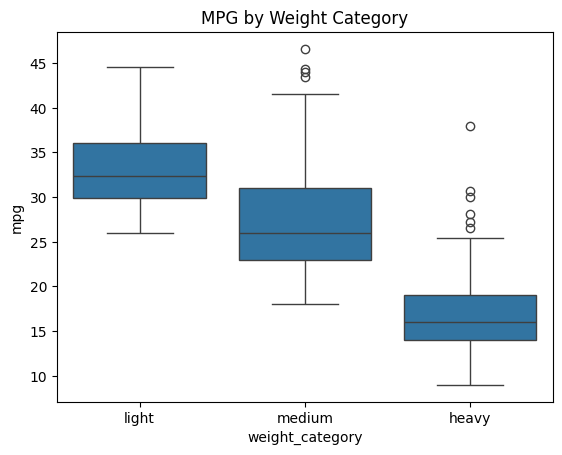

In [61]:
# step4:  Visualization of Binned Features (Weight vs MPG )  Category vs Numerical

sns.boxplot(
    data=df,
    x="weight_category", # x should be categorical
    y="mpg",             # y should be numerical 
    order=['light', 'medium', 'heavy']
)

plt.title("MPG by Weight Category")
plt.show()

# Observ: 
# Outliers in heavy: There are some cars that are heavy and still give good mileage
# Outliers in medium: There are some cars that are medium and still give good mileage

# Horsepower Bins (Quantile-Based Binning)
- **Equal-frequency bins** are often better than fixed bins.

In [62]:
# step1: create 3 equal frequency bins

df['horsepower_bin'] = pd.qcut(
    df['horsepower'],
    q=3,
    labels=['low', 'medium', 'high']
)

print(df[['horsepower', 'horsepower_bin']].sample(10))

     horsepower horsepower_bin
80         86.0         medium
100        88.0         medium
107       100.0         medium
175        70.0            low
308        90.0         medium
186        83.0            low
59         54.0            low
343        58.0            low
341       110.0         medium
122       110.0         medium


In [63]:
# step2: display value counts

print(df['horsepower_bin'].value_counts())

horsepower_bin
medium    144
low       132
high      116
Name: count, dtype: int64


In [64]:
# step3: Display avg MPG by horsepower_bin

print(df.groupby('horsepower_bin', observed=True)['mpg'].mean())

# observation:
# As HP go from low to high, the mean mpg decreases

horsepower_bin
low       31.153788
medium    22.556944
high      15.778448
Name: mpg, dtype: float64


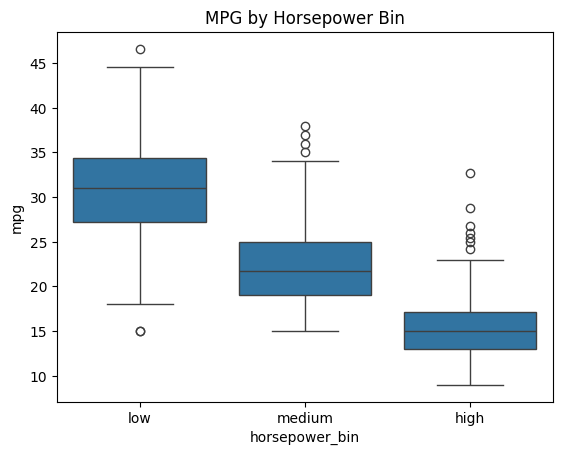

In [65]:
# step4: horsepower_bin vs MPG (category vs numeric)

sns.boxplot(
    data=df,
    x="horsepower_bin", # should be categorical
    y="mpg",            # should be  numerical 
    order=['low', 'medium', 'high']
)

plt.title("MPG by Horsepower Bin")
plt.show()

## Age of Car (Temporal Feature)
- Concept: Time-based feature engineering
- Here car_age is calculated from model_year:
```
car_age = model_year_max_value - model_year
```

In [66]:
# 1) max of model_year
print(df["model_year"].max())

82


In [67]:
# 2)
df["car_age"] = df["model_year"].max() - df["model_year"]

print(df[['model_year', 'car_age']].sample(10))

     model_year  car_age
154          75        7
354          81        1
202          76        6
266          78        4
327          80        2
5            70       12
140          74        8
314          80        2
356          81        1
12           70       12


In [82]:
# 3) show me value_counts
print(df["car_age"].value_counts())

car_age
9     40
4     36
6     34
0     31
7     30
2     29
3     29
1     29
12    29
11    28
10    28
5     28
8     27
Name: count, dtype: int64


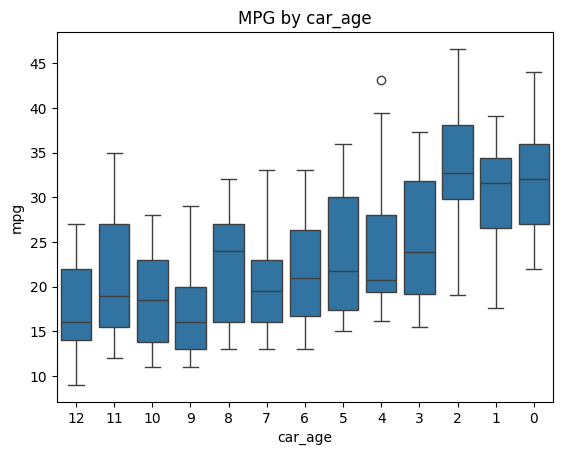

In [87]:
# 4) car_age vs MPG (category vs numeric)

# Get unique car_age values and sort them descending
age_order = sorted(df['car_age'].unique(), reverse=True)

sns.boxplot(
    data=df,
    x="car_age", # should be categorical
    y="mpg",            # should be  numerical 
    order=age_order
)

plt.title("MPG by car_age")
plt.show()

# observ: As the car age decreased, the MPG went up.

# STOP - EXTRA ADDED LATER (It is relevant)

In [68]:
# df
print(df.sample(10))

      mpg  cylinders  displacement  horsepower  weight  acceleration  \
134  16.0          6         258.0       110.0    3632          18.0   
314  26.4          4         140.0        88.0    2870          18.1   
155  15.0          6         250.0        72.0    3158          19.5   
347  37.0          4          85.0        65.0    1975          19.4   
380  36.0          4         120.0        88.0    2160          14.5   
33   19.0          6         232.0       100.0    2634          13.0   
317  34.3          4          97.0        78.0    2188          15.8   
284  20.6          6         225.0       110.0    3360          16.6   
238  33.5          4          98.0        83.0    2075          15.9   
388  26.0          4         156.0        92.0    2585          14.5   

     model_year  origin                        name  power_to_weight  \
134          74     usa                 amc matador         0.030286   
314          80     usa               ford fairmont         0.0

# Extract brand from name

In [69]:
# 1) create a new column

df["brand"] = df["name"].str.split().str[0] # ford escort 2h -> ['ford', 'escort', '2h'] -> ford

print(df[['name', 'brand']].sample(10))

                          name      brand
380           nissan stanza xe     nissan
2           plymouth satellite   plymouth
117                   fiat 128       fiat
359  peugeot 505s turbo diesel    peugeot
7            plymouth fury iii   plymouth
63            pontiac catalina    pontiac
277              peugeot 604sl    peugeot
369  chevrolet cavalier 2-door  chevrolet
96     amc ambassador brougham        amc
284              dodge aspen 6      dodge


In [70]:
# 2) check how many unique values are there in brand column

print(df["brand"].value_counts())

brand
ford             51
chevrolet        43
plymouth         31
amc              28
dodge            28
toyota           25
datsun           23
buick            17
pontiac          16
volkswagen       15
honda            13
mercury          11
oldsmobile       10
mazda            10
peugeot           8
fiat              8
audi              7
vw                6
volvo             6
chrysler          6
renault           5
saab              4
subaru            4
opel              4
chevy             3
cadillac          2
bmw               2
mercedes-benz     2
maxda             2
hi                1
toyouta           1
chevroelt         1
capri             1
mercedes          1
vokswagen         1
triumph           1
nissan            1
Name: count, dtype: int64


In [71]:
# 3) average mpg by brand and origin
brand_mpg = df.groupby(["brand", "origin"])["mpg"].mean().reset_index()

brand_mpg_sorted = brand_mpg.sort_values(by="mpg", ascending=False)

print(brand_mpg_sorted)

# observ: The VW cars from  Europe gives best MPG
# The hi from USA gives the worst mileage

            brand  origin        mpg
36             vw  europe  39.016667
21         nissan   japan  36.000000
32        triumph  europe  35.000000
15          honda   japan  33.761538
27        renault  europe  32.880000
10         datsun   japan  31.113043
17          mazda   japan  30.860000
29         subaru   japan  30.525000
33      vokswagen  europe  29.800000
34     volkswagen  europe  29.106667
12           fiat  europe  28.912500
30         toyota   japan  28.372000
1            audi  europe  26.714286
16          maxda   japan  26.050000
23           opel  europe  25.750000
18       mercedes  europe  25.400000
5           capri     usa  25.000000
28           saab  europe  23.900000
2             bmw  europe  23.750000
24        peugeot  europe  23.687500
19  mercedes-benz  europe  23.250000
31        toyouta   japan  23.000000
11          dodge     usa  22.060714
25       plymouth     usa  21.703226
35          volvo  europe  21.116667
22     oldsmobile     usa  21.100000
7

# Create brand-level efficiency feature

Create a new feature:
“Is this car from a fuel-efficient brand?”

In [72]:
# 1) compute average mpg per brand

brand_avg_series = df.groupby("brand")["mpg"].mean()

print(brand_avg_series.sort_values(ascending=False))

brand
vw               39.016667
nissan           36.000000
triumph          35.000000
honda            33.761538
renault          32.880000
datsun           31.113043
mazda            30.860000
subaru           30.525000
vokswagen        29.800000
volkswagen       29.106667
fiat             28.912500
toyota           28.372000
audi             26.714286
maxda            26.050000
opel             25.750000
mercedes         25.400000
capri            25.000000
saab             23.900000
bmw              23.750000
peugeot          23.687500
mercedes-benz    23.250000
toyouta          23.000000
dodge            22.060714
plymouth         21.703226
volvo            21.116667
oldsmobile       21.100000
chevrolet        20.472093
pontiac          20.012500
cadillac         19.750000
ford             19.694118
buick            19.182353
mercury          19.118182
amc              18.246429
chevy            18.000000
chrysler         17.266667
chevroelt        16.000000
hi                9.00

In [73]:
# 2) Map the Series back to the original dataframe
# map() matches the 'brand' values in df to the index of brand_avg_series
df["brand_avg_mpg"] = df["brand"].map(brand_avg_series)

print(df[['brand', 'brand_avg_mpg']].sample(10))

          brand  brand_avg_mpg
278  volkswagen      29.106667
90      mercury      19.118182
257         amc      18.246429
210      toyota      28.372000
25         ford      19.694118
249  oldsmobile      21.100000
97     plymouth      21.703226
125    plymouth      21.703226
250       dodge      22.060714
31       toyota      28.372000


In [74]:
# 3) binary feature
df["efficient_brand"] = (df["brand_avg_mpg"] > df["mpg"].mean()).astype(int)

print(df[["name", "mpg", "brand_avg_mpg", "efficient_brand"]].sample(10))

                          name   mpg  brand_avg_mpg  efficient_brand
365            ford granada gl  20.2      19.694118                0
199             dodge aspen se  20.0      22.060714                0
293           vw rabbit custom  31.9      39.016667                1
103           chevrolet impala  11.0      20.472093                0
316                dodge aspen  19.1      22.060714                0
47            pontiac firebird  19.0      20.012500                0
285  chevrolet caprice classic  17.0      20.472093                0
260                dodge aspen  18.6      22.060714                0
100              ford maverick  18.0      19.694118                0
374             amc concord dl  23.0      18.246429                0


In [75]:
# 4) How many cars are fuel efficient:
print(df['efficient_brand'].value_counts())

# Observ: 257 cars are not fuel efficient.

efficient_brand
0    257
1    141
Name: count, dtype: int64


# Brand popularity + mpg
- The number of cars from brand dictates its popularity.

In [76]:
# 1) calculate brand frequency
brand_count = df["brand"].value_counts()

print(brand_count)

brand
ford             51
chevrolet        43
plymouth         31
amc              28
dodge            28
toyota           25
datsun           23
buick            17
pontiac          16
volkswagen       15
honda            13
mercury          11
oldsmobile       10
mazda            10
peugeot           8
fiat              8
audi              7
vw                6
volvo             6
chrysler          6
renault           5
saab              4
subaru            4
opel              4
chevy             3
cadillac          2
bmw               2
mercedes-benz     2
maxda             2
hi                1
toyouta           1
chevroelt         1
capri             1
mercedes          1
vokswagen         1
triumph           1
nissan            1
Name: count, dtype: int64


In [77]:
# 2) create a new feature: rank cars popularity based on brand count 

df["brand_popularity"] = df["brand"].map(brand_count)

print(df[["name", "brand", "brand_popularity", "mpg"]].sample(10))

                                  name       brand  brand_popularity   mpg
360                       volvo diesel       volvo                 6  30.7
187  chevrolet chevelle malibu classic   chevrolet                43  17.5
346                             subaru      subaru                 4  32.3
364              oldsmobile cutlass ls  oldsmobile                10  26.6
295        dodge colt hatchback custom       dodge                28  35.7
117                           fiat 128        fiat                 8  29.0
343                     toyota starlet      toyota                25  39.1
312                         datsun 310      datsun                23  37.2
394                          vw pickup          vw                 6  44.0
333                      datsun 280-zx      datsun                23  32.7


In [78]:
# 3) compute average mpg per brand popularity
brand_popularity_avg = df.groupby("brand_popularity")["mpg"].mean()

print(brand_popularity_avg.sort_values(ascending=False))

# Observ: The car that gives best MPG is brand 13 
# The car that gives worst mileage is brand 3

brand_popularity
13    33.761538
5     32.880000
23    31.113043
15    29.106667
25    28.372000
4     26.725000
7     26.714286
8     26.300000
10    25.980000
6     25.800000
1     24.900000
2     23.200000
31    21.703226
43    20.472093
28    20.153571
16    20.012500
51    19.694118
17    19.182353
11    19.118182
3     18.000000
Name: mpg, dtype: float64
